# Examples

This notebooks holds the examples from the paper `Taming the Panda with Python`.

In [ ]:
# Panda hostname/IP and Desk login information of your robot
hostname = '172.16.0.2'
username = 'Dentec'
password = 'Frankenstein'

# panda-py is chatty, activate information log level
import logging
logging.basicConfig(level=logging.INFO)

import panda_py

desk = panda_py.Desk(hostname, username, password)
desk.unlock()
desk.activate_fci()

from panda_py import libfranka

panda = panda_py.Panda(hostname)
gripper = libfranka.Gripper(hostname)

panda.move_to_start(speed_factor=0.05)
# pose = panda.get_pose()
# pose[2,3] -= 0.2
# q = panda_py.ik(pose)
# panda.move_to_joint_position(q, speed_factor=0.05)
# print(panda.get_position())

INFO:desk:Login succesful.
INFO:desk:Taken control.
INFO:panda:Connected to robot (172.16.0.2).
INFO:panda:Panda class destructor invoked (172.16.0.2).
INFO:panda:Stopping active controller (JointTrajectory).


Wylacznie robota (potem trzeba jeszcze do konca go wylaczyc uzywajac deska w przegladarce)

In [8]:
# Panda hostname/IP and Desk login information of your robot
hostname = '172.16.0.2'
username = 'Dentec'
password = 'Frankenstein'

# panda-py is chatty, activate information log level
import logging
logging.basicConfig(level=logging.INFO)

import panda_py

desk = panda_py.Desk(hostname, username, password)
# releases control of robot so that desk can work or other person can control it
desk.lock()
desk.release_control()

INFO:desk:Login succesful.
INFO:desk:Retaken control.
INFO:desk:Releasing control.


## Code Block 2

Connect to the robot using the Panda class. The default gripper from Franka Emika does not support real-time control and can be controlled using the libfranka bindings directly.

In [12]:
from panda_py import libfranka

panda = panda_py.Panda(hostname)
gripper = libfranka.Gripper(hostname)

INFO:panda:Connected to robot (172.16.0.2).
INFO:panda:Panda class destructor invoked (172.16.0.2).
INFO:panda:Stopping active controller (JointTrajectory).


In [14]:
# Get current joint positions (7 angles)
q = panda.q
print(f"Joint Angles: {q}")

# # Get current joint velocities
# dq = panda.dq
# print(f"Joint Velocities: {dq}")

# Get End-Effector Position (3x1 vector)
ee_position = panda.get_position()
print(f"EE Position: {ee_position}")

# Get End-Effector Orientation (Quaternion)
ee_orientation = panda.get_orientation()
print(f"EE Orientation: {ee_orientation}")

import panda_py._core as core

# Print the constant
print("start position")
## start { 0, -1/4 pi, 0, -3/4 pi, 0, 1/2 pi, 1/4 pi}
print(core._JOINT_POSITION_START)

Joint Angles: [-0.01002099 -0.7442835   0.00942065 -2.84843452  0.00937183  2.10544167
  0.79352195]
EE Position: [3.07497155e-01 3.12920732e-05 2.86841416e-01]
EE Orientation: [ 9.99967514e-01 -7.99050241e-03  6.39747045e-04 -8.44165208e-04]
start position
[ 0.         -0.78539816  0.         -2.35619449  0.          1.57079633
  0.78539816]


In [7]:
import numpy as np
import math

# # 1. Define your current joint angles (copied from your output)
# current_q = np.array([0.39177661, 0.00662608, -2.87698304, -3.0230006, 
#                       0.04051641, 3.09066208, 0.5539874])

current_q = panda.q
print(f"Joint Angles: {current_q}")

# 2. Create a target configuration by copying the current one
target_q = current_q.copy()

# 3. Change only the first joint (Index 0) to 0.5
target_q[6] = target_q[6] - 0.05
# target_q[3] = -3*math.pi/4
# target_q[0] = 0
print(f"Joint Angles: {target_q}")

# 4. Command the robot to move
# speed_factor=0.2 moves at 20% speed (safer for testing)ca
panda.move_to_joint_position(target_q, speed_factor=0.1)

INFO:panda:Stopping active controller (JointTrajectory).
INFO:panda:Initializing motion generation (moveToJointPosition).
INFO:motion:Computed joint trajectory: 1 waypoint, duration 0.32 seconds.
INFO:panda:Starting new controller (JointTrajectory).


Joint Angles: [ 0.00801565 -0.73624151 -0.0070895  -2.84820243 -0.01258858  2.09472008
  0.65149668]
Joint Angles: [ 0.00801565 -0.73624151 -0.0070895  -2.84820243 -0.01258858  2.09472008
  0.60149668]


True

## Code Block 3

Simple motion generation in joint space. The call to `get_pose` produces a $4\times 4$ matrix representing the homogeneous transform from robot base to end-effector. The indices $2,3$ refer to third row and fourth column respectively, i.e. the z-coordinate. The position in z is lowered by $0.1\mathrm{m}$ and passed to the inverse kinematics function to produce joint positions. Finally the call to `move_to_joint_position` generates a motion from the current to the desired joint potions.

In [24]:
print(panda.get_position())

[ 0.30285349 -0.00435815  0.0572252 ]


In [25]:
# panda.move_to_start(speed_factor=0.05)
pose = panda.get_pose()
pose[2,3] += 0.03
q = panda_py.ik(pose)
panda.move_to_joint_position(q, speed_factor=0.05)
print(panda.get_position())

INFO:panda:Stopping active controller (JointTrajectory).
INFO:panda:Initializing motion generation (moveToJointPosition).
INFO:motion:Computed joint trajectory: 1 waypoint, duration 23.81 seconds.
INFO:panda:Starting new controller (JointTrajectory).


[ 0.3048077  -0.00476945  0.08740068]


In [1]:
panda.move_to_start()
pose = panda.get_pose()
pose[2,3] -= .05
q = panda_py.ik(pose)
# panda.move_to_joint_position(q)

NameError: name 'panda' is not defined

## Code Block 4

Simple motion generation in Cartesian space. The z-coordinate of the current end-effector pose is lowered by $0.1\mathrm{m}$ as in Code Block 3. However the resulting pose is passed directly to `move_to_pose` to produce a motion in Cartesian space.

In [ ]:
panda.move_to_start(speed_factor=0.05)
pose = panda.get_pose()
print(pose)
pose[2,3] += .1
panda.move_to_pose(pose, speed_factor=0.05)

INFO:panda:Stopping active controller (JointTrajectory).
INFO:panda:Initializing motion generation (moveToJointPosition).
INFO:motion:Computed joint trajectory: 1 waypoint, duration 7.76 seconds.
INFO:panda:Starting new controller (JointTrajectory).


[[ 9.99959244e-01 -7.30899043e-03 -2.97269284e-03  3.05797786e-01]
 [-7.31551886e-03 -9.99961214e-01 -2.19124073e-03 -7.27442357e-04]
 [-2.95656178e-03  2.21289822e-03 -9.99993181e-01  4.87069029e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


## Chwytak

In [30]:
# Panda hostname/IP and Desk login information of your robot
hostname = '172.16.0.2'
username = 'Dentec'
password = 'Frankenstein'

# panda-py is chatty, activate information log level
import logging
logging.basicConfig(level=logging.INFO)

import panda_py

desk = panda_py.Desk(hostname, username, password)
desk.unlock()
desk.activate_fci()

from panda_py import libfranka

panda = panda_py.Panda(hostname)
gripper = libfranka.Gripper(hostname)

print(panda.get_state())
print(panda.get_model())
# gripper.grasp(0, 0.2, 10, 0.04, 0.04)
gripper.move(0.08, 0.2)

INFO:desk:Login succesful.
INFO:desk:Retaken control.
INFO:panda:Connected to robot (172.16.0.2).
INFO:panda:Panda class destructor invoked (172.16.0.2).
INFO:panda:Stopping active controller (JointTrajectory).


{"O_T_EE": [0.99997,-0.00622096,0.00155694,0,-0.00622155,-0.999971,0.00037198,0,0.00155462,-0.000381662,-0.999999,0,0.307503,-0.0012059,0.28691,1], "O_T_EE_d": [0.99997,-0.00621819,0.00155833,0,-0.00621879,-0.999971,0.000377958,0,0.00155596,-0.000387645,-0.999999,0,0.307503,-0.00120502,0.286911,1], "F_T_NE": [0.7071,-0.7071,0,0,0.7071,0.7071,0,0,0,0,1,0,0,0,0.1034,1], "NE_T_EE": [1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1], "F_T_EE": [0.7071,-0.7071,0,0,0.7071,0.7071,0,0,0,0,1,0,0,0,0.1034,1], "EE_T_K": [1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1], "m_ee": 0.73, "F_x_Cee": [-0.01,0,0.03], "I_ee": [0.001,0,0,0,0.0025,0,0,0,0.0017], "m_load": 0, "F_x_Cload": [0,0,0], "I_load": [0,0,0,0,0,0,0,0,0], "m_total": 0.73, "F_x_Ctotal": [-0.01,0,0.03], "I_total": [0.001,0,0,0,0.0025,0,0,0,0.0017], "elbow": [7.25926e-05,-1], "elbow_d": [8.07998e-05,-1], "elbow_c": [8.07998e-05,-1], "delbow_c": [0,0], "ddelbow_c": [0,0], "tau_J": [-0.278044,-4.91789,-0.260264,21.8334,0.745221,2.26379,-0.0290389], "tau_J_d": [0,0,0,0,0,0

True

## Code Block 5

Using the integrated logging mechanism, the libfranka `RobotState` can be logged at a frequency of $1\mathrm{kHz}$. This example creates two end-effector poses `T_0` and `T_1` based on the starting pose, displaced $0.25\mathrm{m}$ to the left and right respectively. Before a motion is generated between these poses, logging is enabled for this Panda instance (line 9). The enable logging function takes the buffer size in number of steps as argument. As such, $2e3$ steps at $1\mathrm{kHz}$ correspond to a buffer holding the state of the past 2 seconds. After the motion is finished, logging is disabled and the buffer retrieved (line 14).

In [204]:
from panda_py import constants
import numpy as np

T_0 = panda_py.fk(constants.JOINT_POSITION_START)
T_0[1, 3] = 0.25
T_1 = T_0.copy()
T_1[1, 3] = -0.25

panda.move_to_pose(T_0)
panda.enable_logging(40000)
panda.move_to_pose(T_1,
                   speed_factor=0.05)
panda.disable_logging()
log = panda.get_log()

panda.move_to_pose(T_0)
panda.enable_logging(10000)
panda.move_to_joint_position(panda_py.ik(T_1), speed_factor=0.05)
panda.disable_logging()
joint_log = panda.get_log()

INFO:panda:Initializing motion generation (moveToPose).
INFO:motion:Computed Cartesian trajectory: 1 waypoint, duration 0.87 seconds.
INFO:panda:Starting new controller (CartesianTrajectory).
INFO:panda:Stopping active controller (CartesianTrajectory).
INFO:panda:Initializing motion generation (moveToPose).
INFO:motion:Computed Cartesian trajectory: 1 waypoint, duration 5.85 seconds.
INFO:panda:Starting new controller (CartesianTrajectory).
INFO:panda:Stopping active controller (CartesianTrajectory).
INFO:panda:Initializing motion generation (moveToPose).
INFO:motion:Computed Cartesian trajectory: 1 waypoint, duration 1.55 seconds.
INFO:panda:Starting new controller (CartesianTrajectory).
INFO:panda:Stopping active controller (CartesianTrajectory).
INFO:panda:Initializing motion generation (moveToJointPosition).
INFO:motion:Computed joint trajectory: 1 waypoint, duration 11.03 seconds.
INFO:panda:Starting new controller (JointTrajectory).


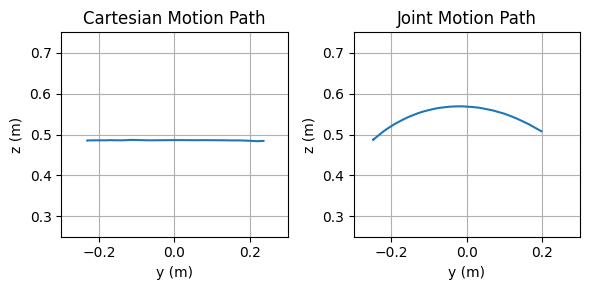

In [205]:
from matplotlib import pyplot as plt

def plot(O_T_EE, ax, title: str):
  ax.plot(O_T_EE[:,13], O_T_EE[:,14])
  ax.set_xlim(-0.3,0.3)
  ax.set_ylim(0.25,0.75)
  ax.set_xlabel('y (m)')
  ax.set_ylabel('z (m)')
  ax.grid(True)
  ax.set_title(title)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(6,3))
plot(np.array(log['O_T_EE']), ax0, 'Cartesian Motion Path')
plot(np.array(joint_log['O_T_EE']), ax1, 'Joint Motion Path')
fig.tight_layout()

## Code Block 6

Running a panda-py controller. After initializing the controller, the current position and orientation are stored in `x0` and `q0` respectively, where `q0` is a quaternion representation of the end-effector orientation. After starting the controller, a `PandaContext` is created from the Panda object (line 10). `PandaContext` is a convenient context manager that executes a loop at a fixed frequency for an optional amount of time. The call to `PandaContext.ok` throttles the loop and also raises any control exceptions that may have been raised by libfranka. Use of `PandaContext` is optional and users are free to manage the control flow how they wish. In this example a periodic linear displacement along the y-axis is added to the initial pose (line 13). This results in the end-effector moving periodically from left to right in straight lines.

> **Info**
>
> This Code Block doesn't run well inside IPython notebooks and may not finish successfully. Please run the example located at `examples/cartesian_impedance.py` instead.


## Code Block 7

Code Block 7: Resolved rate controller with reactive manipulability maximization. This example is from the Robotics Toolbox for Python. To run it on the real hardware with panda-py requires only connecting the inputs and outputs of the control loop to panda-py, i.e., using the joint positions `Panda.q` and providing the control signal to `IntegrateVelocity.set control`. Additionally, the inequality constraints to avoid the joint limits were removed, as panda-py controllers already have integrated joint limit avoidance using impedance control.

> **Info**
>
> This Code Block doesn't run well inside IPython notebooks and may not finish successfully. Please run the example located at `examples/mmc.py` instead.